<a href="https://colab.research.google.com/github/Ahad17-sys/brain-tumor-classification-densenet-unet/blob/main/MP_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install -q transformers datasets accelerate torch joblib

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import re
import joblib

In [ ]:
tweet_data = pd.read_csv("/content/drive/MyDrive/stock_tweets.csv")
stock_data = pd.read_csv("/content/drive/MyDrive/stock_yfinance_data.csv")

print("Tweet Data Shape:", tweet_data.shape)
print("Stock Data Shape:", stock_data.shape)

Tweet Data Shape: (80793, 4)
Stock Data Shape: (6300, 8)


In [ ]:
tweet_data.head()

,Date,Tweet,Stock Name,Company Name
0,2024-09-29 23:41:16+00:00,Mainstream media has done an amazing job at br...,TSLA,"Tesla, Inc."
1,2024-09-29 23:24:43+00:00,Tesla delivery estimates are at around 364k fr...,TSLA,"Tesla, Inc."
2,2024-09-29 23:18:08+00:00,3/ Even if I include 63.0M unvested RSUs as of...,TSLA,"Tesla, Inc."
3,2024-09-29 22:40:07+00:00,@RealDanODowd @WholeMarsBlog @Tesla Hahaha why...,TSLA,"Tesla, Inc."
4,2024-09-29 22:27:05+00:00,"@RealDanODowd @Tesla Stop trying to kill kids,...",TSLA,"Tesla, Inc."


In [ ]:
stock_data.head()

,Date,Open,High,Low,Close,Adj Close,Volume,Stock Name
0,9/30/2023,260.333344,263.043335,258.333344,258.493347,258.493347,53868000,TSLA
1,10/1/2023,259.466675,260.260010,254.529999,258.406677,258.406677,51094200,TSLA
2,10/4/2023,265.500000,268.989990,258.706665,260.510010,260.510010,91449900,TSLA
3,10/5/2023,261.600006,265.769989,258.066681,260.196655,260.196655,55297800,TSLA
4,10/6/2023,258.733337,262.220001,257.739990,260.916656,260.916656,43898400,TSLA


In [ ]:
stock_data["Date"] = pd.to_datetime(stock_data["Date"]).dt.strftime("%Y-%m-%d")

In [ ]:
print(f'Last tweet date: {max(tweet_data.Date)}')
print(f'First tweet date: {min(tweet_data.Date)}')
print(f'Last stock date: {max(stock_data.Date)}')
print(f'First stock date: {min(stock_data.Date)}')

Last tweet date: 2024-09-29 23:41:16+00:00
First tweet date: 2023-09-30 00:06:02+00:00
Last stock date: 2024-09-29
First stock date: 2023-09-30


In [ ]:
stock_data['Fluctuation'] = stock_data.High - stock_data.Low
stock_data['Price_Gain'] = stock_data.Close - stock_data.Open
stock_data['Total_Valuation_EOD'] = stock_data.Volume * stock_data.Close

In [ ]:
stock_data.head()

,Date,Open,High,Low,Close,Adj Close,Volume,Stock Name,Fluctuation,Price_Gain,Total_Valuation_EOD
0,2023-09-30,260.333344,263.043335,258.333344,258.493347,258.493347,53868000,TSLA,4.709992,-1.839996,1.392452e+10
1,2023-10-01,259.466675,260.260010,254.529999,258.406677,258.406677,51094200,TSLA,5.730011,-1.059998,1.320308e+10
2,2023-10-04,265.500000,268.989990,258.706665,260.510010,260.510010,91449900,TSLA,10.283325,-4.989990,2.382361e+10
3,2023-10-05,261.600006,265.769989,258.066681,260.196655,260.196655,55297800,TSLA,7.703308,-1.403351,1.438830e+10
4,2023-10-06,258.733337,262.220001,257.739990,260.916656,260.916656,43898400,TSLA,4.480011,2.183319,1.145382e+10


In [ ]:
tweet_data = tweet_data.dropna(subset=["Tweet"])
tweet_data['Tweet'] = tweet_data['Tweet'].astype(str)

In [ ]:
tweet_data['Tweet'] = (
    tweet_data['Tweet']
    .str.lower()
    .str.replace(r'@[A-Za-z0-9_]+', '', regex=True)
    .str.replace(r'#[A-Za-z0-9_]+', '', regex=True)
    .str.replace(r'http\S+|www\.\S+', '', regex=True)
    .str.replace(r'\[.*?\]', ' ', regex=True)
    .str.replace(r'[^a-z]', ' ', regex=True)
    .str.replace(r'\s+', ' ', regex=True)
    .str.strip()
)

In [ ]:
tweet_data[['Tweet']].head()

,Tweet
0,mainstream media has done an amazing job at br...
1,tesla delivery estimates are at around k from ...
2,even if i include m unvested rsus as of additi...
3,hahaha why are you still trying to stop tesla ...
4,stop trying to kill kids you sad deranged old man


In [ ]:
from transformers import pipeline

sentiment_model = pipeline(
    "sentiment-analysis",
    model="cardiffnlp/twitter-roberta-base-sentiment",
    tokenizer="cardiffnlp/twitter-roberta-base-sentiment",
    device=0
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/747 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/499M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

In [ ]:
def roberta_batch_sentiment(texts, batch_size=16):

    sentiments = []

    for i in range(0, len(texts), batch_size):

        batch = texts[i:i + batch_size].tolist()
        results = sentiment_model(batch)

        for r in results:

            if r['label'] == 'LABEL_2':
                sentiments.append(1)

            elif r['label'] == 'LABEL_0':
                sentiments.append(-1)

            else:
                sentiments.append(0)

    return sentiments

In [ ]:
tweet_data['Sentiment'] = roberta_batch_sentiment(
    tweet_data['Tweet'],
    batch_size=16
)

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


In [ ]:
tweet_data.head()

,Date,Tweet,Stock Name,Company Name,Sentiment
0,2024-09-29 23:41:16+00:00,mainstream media has done an amazing job at br...,TSLA,"Tesla, Inc.",1
1,2024-09-29 23:24:43+00:00,tesla delivery estimates are at around k from ...,TSLA,"Tesla, Inc.",0
2,2024-09-29 23:18:08+00:00,even if i include m unvested rsus as of additi...,TSLA,"Tesla, Inc.",0
3,2024-09-29 22:40:07+00:00,hahaha why are you still trying to stop tesla ...,TSLA,"Tesla, Inc.",-1
4,2024-09-29 22:27:05+00:00,stop trying to kill kids you sad deranged old man,TSLA,"Tesla, Inc.",-1


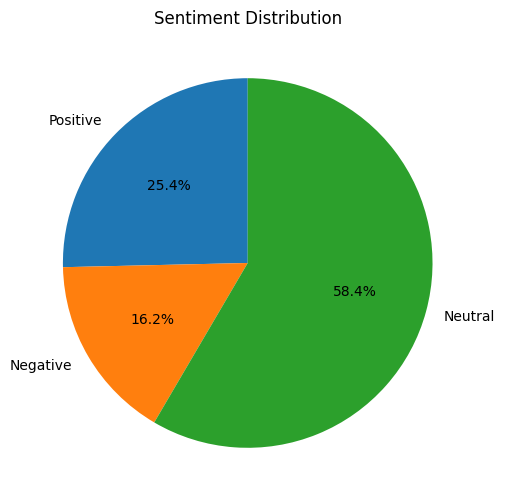

In [ ]:
positive_count = (tweet_data['Sentiment'] > 0).sum()
negative_count = (tweet_data['Sentiment'] < 0).sum()
neutral_count = (tweet_data['Sentiment'] == 0).sum()

labels = ['Positive', 'Negative', 'Neutral']
sizes = [positive_count, negative_count, neutral_count]

plt.figure(figsize=(6,6))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90)
plt.title("Sentiment Distribution")
plt.show()

In [ ]:
tweet_data['Date_string'] = tweet_data['Date'].astype(str).str.split(" ").str[0]
stock_data['Date_string'] = stock_data['Date']

In [ ]:
daily_sentiment = tweet_data.groupby(
    ['Date_string','Stock Name']
).agg({
    'Sentiment':'mean',
    'Tweet':'count'
}).reset_index()

daily_sentiment.rename(columns={'Tweet':'Tweet_Count'},inplace=True)

In [ ]:
daily_sentiment.head()

,Date_string,Stock Name,Sentiment,Tweet_Count
0,2023-09-30,AAPL,-0.428571,7
1,2023-09-30,AMD,0.500000,6
2,2023-09-30,AMZN,0.000000,5
3,2023-09-30,DIS,0.000000,1
4,2023-09-30,GOOG,0.000000,1


In [ ]:
data = pd.merge(
    daily_sentiment,
    stock_data,
    on=['Date_string','Stock Name']
)

data = data.dropna()

In [ ]:
data.head()

,Date_string,Stock Name,Sentiment,Tweet_Count,Date,Open,High,Low,Close,Adj Close,Volume,Fluctuation,Price_Gain,Total_Valuation_EOD
0,2023-09-30,AAPL,-0.428571,7,2023-09-30,143.660004,144.380005,141.279999,141.500000,140.478485,89056700,3.100006,-2.160004,1.260152e+10
1,2023-09-30,AMD,0.500000,6,2023-09-30,102.080002,104.440002,101.989998,102.900002,102.900002,57636700,2.450004,0.820000,5.930817e+09
2,2023-09-30,AMZN,0.000000,5,2023-09-30,165.800003,166.392502,163.699493,164.251999,164.251999,56848000,2.693008,-1.548004,9.337398e+09
3,2023-09-30,DIS,0.000000,1,2023-09-30,173.100006,173.679993,169.100006,169.169998,169.169998,13978000,4.579987,-3.930008,2.364658e+09
4,2023-09-30,GOOG,0.000000,1,2023-09-30,134.324997,135.589996,133.000000,133.265503,133.265503,35294000,2.589996,-1.059494,4.703473e+09


In [ ]:
data['trend'] = (data['Close'].shift(-1) > data['Close'].shift(-1)).astype(int)
data = data.dropna()

In [ ]:
data[['Sentiment','trend']].head()

,Sentiment,trend
0,-0.428571,0
1,0.500000,0
2,0.000000,0
3,0.000000,0
4,0.000000,0


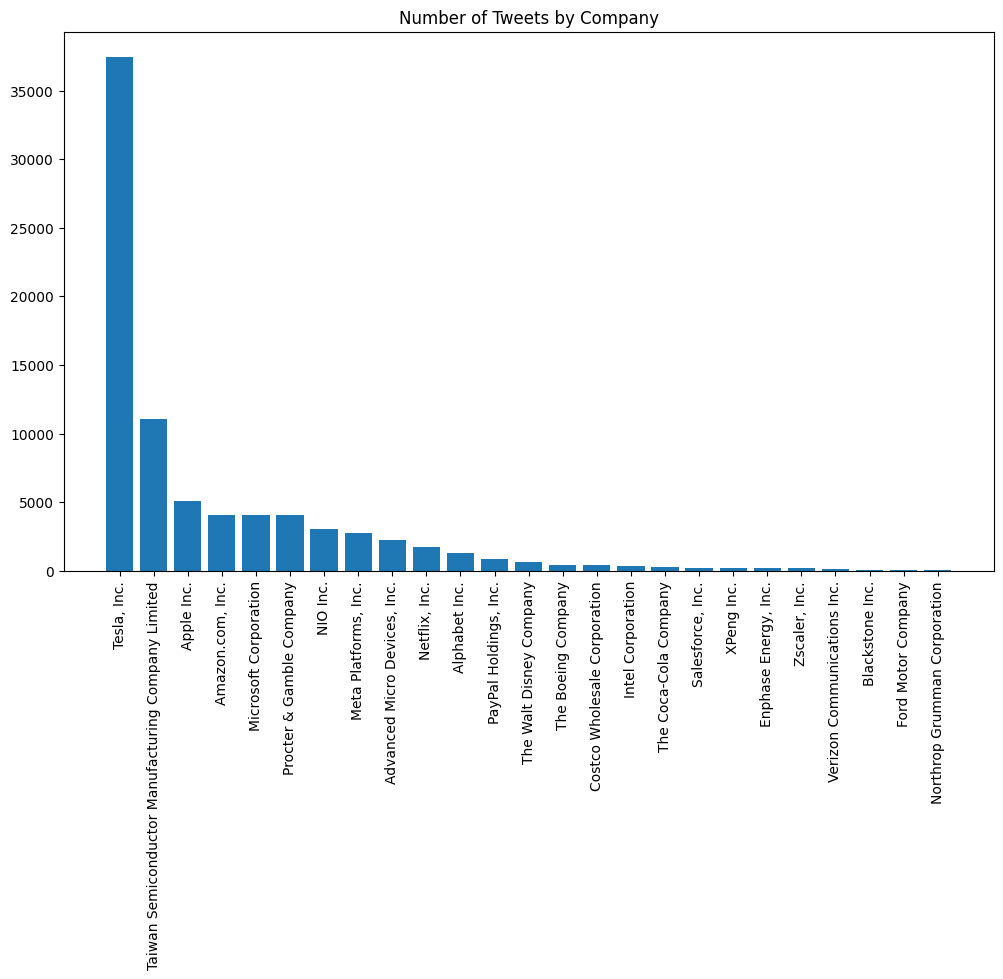

In [ ]:
company_counts = tweet_data['Company Name'].value_counts()

plt.figure(figsize=(12,7))
plt.bar(company_counts.index, company_counts.values)
plt.xticks(rotation=90)
plt.title("Number of Tweets by Company")
plt.show()

In [ ]:
df_transformer = tweet_data[['Tweet','Sentiment']].copy()

df_transformer['label'] = df_transformer['Sentiment'].map({
    -1: 0,
     0: 1,
     1: 2
})

df_transformer = df_transformer.dropna()

In [ ]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    df_transformer[['Tweet','label']],
    test_size=0.2,
    random_state=42,
    stratify=df_transformer['label']
)

In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

model_name = "cardiffnlp/twitter-roberta-base-sentiment"

tokenizer = AutoTokenizer.from_pretrained(model_name)

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=3
)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
from datasets import Dataset

train_dataset = Dataset.from_pandas(train_df)
test_dataset = Dataset.from_pandas(test_df)

In [ ]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    learning_rate=2e-5,
    weight_decay=0.01,
    logging_steps=200,
    save_steps=500,
    fp16=True
)

In [ ]:
def tokenize(batch):

    return tokenizer(
        batch["Tweet"],
        padding="max_length",
        truncation=True,
        max_length=128
    )

In [ ]:
train_dataset = train_dataset.map(tokenize, batched=True)
test_dataset = test_dataset.map(tokenize, batched=True)

Map:   0%|          | 0/64634 [00:00<?, ? examples/s]

Map:   0%|          | 0/16159 [00:00<?, ? examples/s]

In [ ]:
train_dataset.set_format(
    type="torch",
    columns=["input_ids","attention_mask","label"]
)

test_dataset.set_format(
    type="torch",
    columns=["input_ids","attention_mask","label"]
)

In [ ]:
from transformers import Trainer
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

In [ ]:
def compute_metrics(eval_pred):

    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average='weighted'
    )

    acc = accuracy_score(labels, preds)

    return {
        "accuracy": acc,
        "f1": f1,
        "precision": precision,
        "recall": recall
    }

In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics
)

In [ ]:
trainer.train()

Step,Training Loss
200,0.282776
400,0.290386
600,0.267182
800,0.250036
1000,0.244792
1200,0.255286
1400,0.243094
1600,0.261108
1800,0.244145
2000,0.239919


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=12120, training_loss=0.14859339608611052, metrics={'train_runtime': 2082.5583, 'train_samples_per_second': 93.108, 'train_steps_per_second': 5.82, 'total_flos': 1.2754554481073664e+16, 'train_loss': 0.14859339608611052, 'epoch': 3.0})

In [ ]:
results = trainer.evaluate()
print(results)

{'eval_loss': 0.2858044505119324, 'eval_accuracy': 0.945912494585061, 'eval_f1': 0.946100966079254, 'eval_precision': 0.9471136886750886, 'eval_recall': 0.945912494585061, 'eval_runtime': 29.7855, 'eval_samples_per_second': 542.513, 'eval_steps_per_second': 33.909, 'epoch': 3.0}


In [ ]:
def extract_embeddings(dataset, model):

    embeddings = []
    labels = []

    loader = torch.utils.data.DataLoader(dataset, batch_size=32)

    with torch.no_grad():

        for batch in loader:

            input_ids = batch["input_ids"].to(model.device)
            attention_mask = batch["attention_mask"].to(model.device)

            outputs = model.roberta(
                input_ids=input_ids,
                attention_mask=attention_mask
            )

            cls_embeddings = outputs.last_hidden_state[:,0,:]

            embeddings.append(cls_embeddings.cpu().numpy())
            labels.append(batch["label"].cpu().numpy())

    embeddings = np.vstack(embeddings)
    labels = np.hstack(labels)

    return embeddings, labels

In [ ]:
X_train_embed, y_train_embed = extract_embeddings(train_dataset, model)

In [ ]:
X_test_embed, y_test_embed = extract_embeddings(test_dataset, model)

In [ ]:
financial_features = data[['Fluctuation','Price_Gain','Volume','Sentiment','Tweet_Count']].values

repeat_factor = int(np.ceil(len(X_train_embed) / len(financial_features)))

financial_features_expanded = np.tile(financial_features, (repeat_factor, 1))

financial_features_expanded = financial_features_expanded[:len(X_train_embed)]

X_train_final = np.hstack([X_train_embed, financial_features_expanded])

In [ ]:
repeat_factor_test = int(np.ceil(len(X_test_embed) / len(financial_features)))

financial_features_test = np.tile(financial_features, (repeat_factor_test, 1))

financial_features_test = financial_features_test[:len(X_test_embed)]

X_test_final = np.hstack([X_test_embed, financial_features_test])

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=500,
    max_depth=20,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_final, y_train_embed)

RandomForestClassifier(max_depth=20, n_estimators=500, n_jobs=-1,
                       random_state=42)

In [ ]:
import joblib

joblib.dump(
    rf_model,
    "/content/drive/MyDrive/stock_project/hybrid_roberta_rf_model.pkl"
)

model.save_pretrained(
    "/content/drive/MyDrive/stock_project/finetuned_roberta_model"
)

tokenizer.save_pretrained(
    "/content/drive/MyDrive/stock_project/finetuned_roberta_model"
)

print("Models saved successfully to Google Drive")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Models saved successfully to Google Drive


In [ ]:
rf_preds = rf_model.predict(X_test_final)

rf_preds[:10]

array([0, 0, 1, 0, 1, 1, 1, 1, 1, 1])

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

print("Hybrid Model Accuracy:", accuracy_score(y_test_embed, rf_preds))

print("\nClassification Report:\n")

print(classification_report(
    y_test_embed,
    rf_preds,
    target_names=["Negative","Neutral","Positive"]
))

Hybrid Model Accuracy: 0.9490067454669224

Classification Report:

              precision    recall  f1-score   support

    Negative       0.95      0.91      0.93      2618
     Neutral       0.95      0.97      0.96      9443
    Positive       0.96      0.93      0.94      4098

    accuracy                           0.95     16159
   macro avg       0.95      0.94      0.94     16159
weighted avg       0.95      0.95      0.95     16159



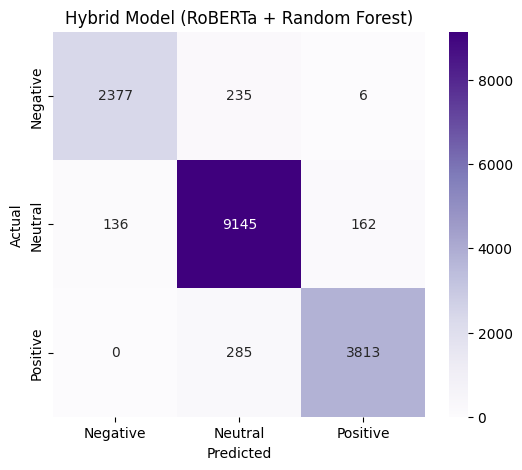

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test_embed, rf_preds)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Purples',
    xticklabels=['Negative','Neutral','Positive'],
    yticklabels=['Negative','Neutral','Positive']
)

plt.title("Hybrid Model (RoBERTa + Random Forest)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

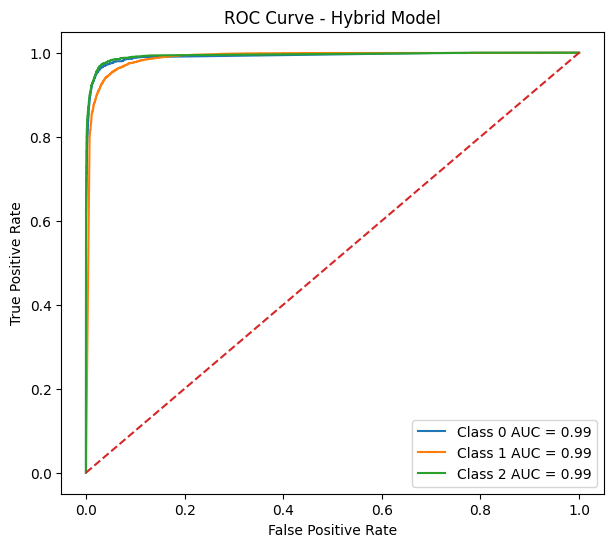

In [ ]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import numpy as np

rf_probs = rf_model.predict_proba(X_test_final)

y_test_bin = label_binarize(y_test_embed, classes=[0,1,2])

plt.figure(figsize=(7,6))

for i in range(3):

    fpr, tpr, _ = roc_curve(y_test_bin[:, i], rf_probs[:, i])

    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f'Class {i} AUC = {roc_auc:.2f}')

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Hybrid Model")
plt.legend()
plt.show()

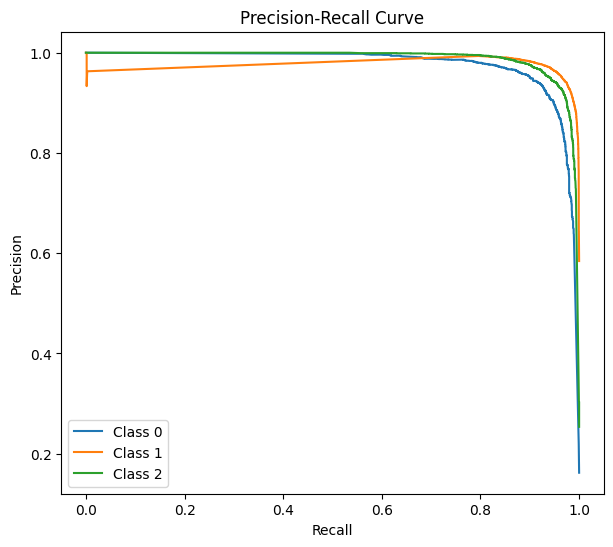

In [ ]:
from sklearn.metrics import precision_recall_curve

plt.figure(figsize=(7,6))

for i in range(3):

    precision, recall, _ = precision_recall_curve(
        y_test_bin[:, i],
        rf_probs[:, i]
    )

    plt.plot(recall, precision, label=f'Class {i}')

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()

In [ ]:
import pandas as pd

results_df = pd.DataFrame()

results_df['Actual'] = y_test_embed
results_df['Predicted'] = rf_preds

label_map = {
    0: "Negative",
    1: "Neutral",
    2: "Positive"
}

results_df['Actual_Label'] = results_df['Actual'].map(label_map)
results_df['Predicted_Label'] = results_df['Predicted'].map(label_map)

In [ ]:
import numpy as np

sample_16 = results_df.sample(n=16, random_state=np.random.randint(0,100000))


sample_16['Tweet'] = test_df.iloc[sample_16.index]['Tweet'].values


def highlight(row):
    if row['Actual_Label'] == row['Predicted_Label']:
        return ['background-color: lightgreen'] * len(row)
    else:
        return ['background-color: salmon'] * len(row)


styled = sample_16[['Tweet','Actual_Label','Predicted_Label']].style.apply(highlight, axis=1)

styled

,Tweet,Actual_Label,Predicted_Label
595,aapl amzn both miss badly time for everyone to go back into safer stocks like biotech xbi,Neutral,Neutral
13189,lol that s the sound of folksy load up tsla at because q q gonna be even bigger never mind the p e is already and competition like rivn heat up and recession likely,Neutral,Neutral
7110,faangs are too extended what s everyone talking about aapl amzn fb nflx,Neutral,Neutral
12420,yeahhhh buddy tsla,Neutral,Neutral
3386,easily the busiest we have ever seen the parking lot at giga berlin from latest drone video tsla,Positive,Positive
12897,queue up uncle i need a carry,Neutral,Neutral
4675,mhmmmmm sure,Neutral,Neutral
10468,this is how long ago you could have bought each security at today s price spy months ago msft months ago googl months ago qqq months ago pltr months ago amd months ago amzn months ago roku months ago nflx months ago fb months ago brutal,Neutral,Neutral
357,my eod price target close is tsla,Neutral,Neutral
11460,great to see facebook taken down its about time they pay the piper fb,Neutral,Positive


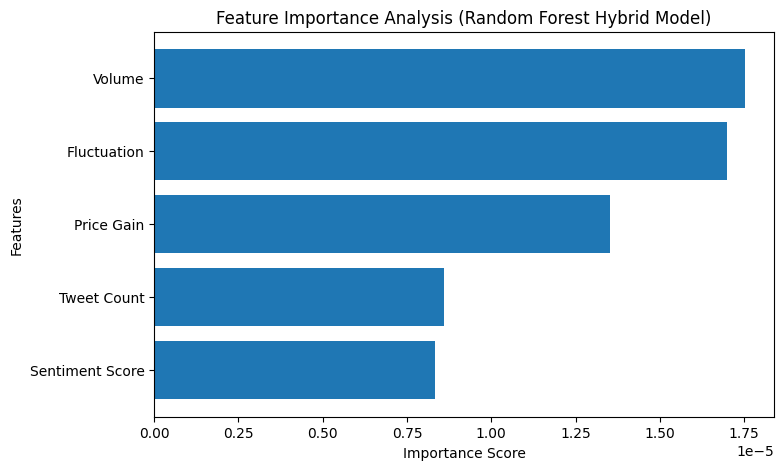

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

feature_names = [
    "Fluctuation",
    "Price Gain",
    "Volume",
    "Sentiment Score",
    "Tweet Count"
]

importances = rf_model.feature_importances_

financial_importance = importances[-5:]

feature_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": financial_importance
})

feature_df = feature_df.sort_values(by="Importance", ascending=True)

plt.figure(figsize=(8,5))

plt.barh(feature_df["Feature"], feature_df["Importance"])

plt.title("Feature Importance Analysis (Random Forest Hybrid Model)")
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.show()

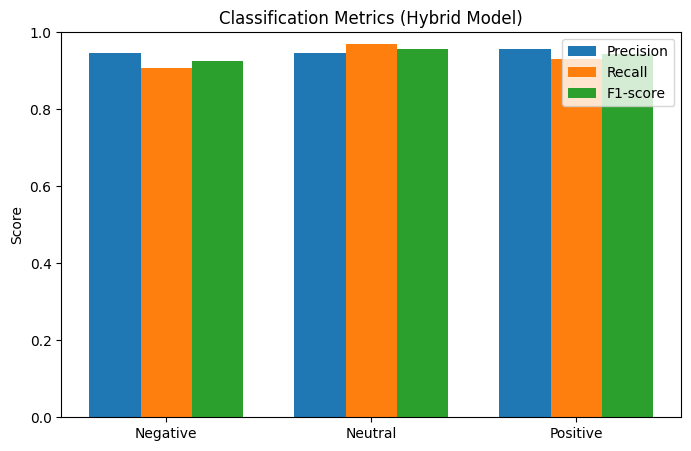

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_fscore_support

precision, recall, f1, _ = precision_recall_fscore_support(
    y_test_embed,
    rf_preds
)

classes = ["Negative", "Neutral", "Positive"]

x = np.arange(len(classes))
width = 0.25

plt.figure(figsize=(8,5))

plt.bar(x - width, precision, width, label="Precision")
plt.bar(x, recall, width, label="Recall")
plt.bar(x + width, f1, width, label="F1-score")

plt.xticks(x, classes)

plt.ylim(0,1)

plt.title("Classification Metrics (Hybrid Model)")
plt.ylabel("Score")

plt.legend()

plt.show()

In [ ]:
!pip install gradio

In [ ]:

import gradio as gr
import torch
import numpy as np
import joblib
from transformers import AutoTokenizer, AutoModelForSequenceClassification

tokenizer = AutoTokenizer.from_pretrained(
"/content/drive/MyDrive/stock_project/finetuned_roberta_model"
)

model = AutoModelForSequenceClassification.from_pretrained(
"/content/drive/MyDrive/stock_project/finetuned_roberta_model"
)

rf_model = joblib.load(
"/content/drive/MyDrive/stock_project/hybrid_roberta_rf_model.pkl"
)

model.eval()

label_map = {
    0: "Negative",
    1: "Neutral",
    2: "Positive"
}

def predict_sentiment(tweet):

    inputs = tokenizer(
        tweet,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=128
    )

    with torch.no_grad():

        outputs = model(**inputs)

        embedding = model.roberta(**inputs).last_hidden_state[:,0,:].cpu().numpy()

    financial_features = np.array([[0,0,0,0,0]])

    X_input = np.hstack([embedding, financial_features])

    rf_probs = rf_model.predict_proba(X_input)[0]

    prediction = np.argmax(rf_probs)

    confidence = rf_probs[prediction] * 100

    return label_map[prediction], f"{confidence:.2f}%"


css = """

body {
    background-color: #f5f1e6;
}

.gradio-container {
    background-color: #f5f1e6;
    font-family: 'Segoe UI', sans-serif;
}

/* Headings */
h1, h2, h3, h4 {
    color: black !important;
}

/* Input panel */
.input-box {
    background-color: #e8f0e3;
    border-radius: 12px;
    padding: 20px;
    border: 2px solid #6b8e23;
}

/* Output panel */
.output-box {
    background-color: #e8f0e3;
    border-radius: 12px;
    padding: 20px;
    border: 2px solid #556b2f;
}

/* Text fields */
textarea, input {
    background-color: #ffffff !important;
    color: black !important;
}

/* Button */
button {
    background-color: #6b8e23 !important;
    color: white !important;
    border-radius: 8px !important;
}

button:hover {
    background-color: #556b2f !important;
}

"""

with gr.Blocks(css=css) as demo:

    gr.Markdown(
        """
        # Stock Tweet Sentiment Analyzer

        """
    )

    with gr.Row():

        with gr.Column(elem_classes="input-box"):

            gr.Markdown("### Input Tweet")

            tweet_input = gr.Textbox(
                label="Enter Tweet",
                placeholder="Type a tweet about stocks..."
            )

            analyze_btn = gr.Button("Analyze Tweet")

        with gr.Column(elem_classes="output-box"):

            gr.Markdown("### Prediction Result")

            sentiment_output = gr.Textbox(label="Predicted Sentiment")

            confidence_output = gr.Textbox(label="Confidence Level")

    analyze_btn.click(
        predict_sentiment,
        inputs=tweet_input,
        outputs=[sentiment_output, confidence_output]
    )

demo.launch()

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

/tmp/ipykernel_3617/4086018184.py:107: DeprecationWarning: The 'css' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'css' to Blocks.launch() instead.
  with gr.Blocks(css=css) as demo:


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://7a06c06d9dfe566bce.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
